In [1]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("Environment ready.")


Environment ready.


In [2]:

!mkdir -p /root/.kaggle
!cp /content/kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle configured.")


cp: cannot stat '/content/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle configured.


In [3]:
!kaggle datasets download -d olistbr/brazilian-ecommerce

print("Download complete.")


Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'
Download complete.


In [4]:
import zipfile

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:

    zip_ref.extractall("dataset")

print("Extraction complete.")


Extraction complete.


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:

orders = pd.read_csv("dataset/olist_orders_dataset.csv")
customers = pd.read_csv("dataset/olist_customers_dataset.csv")
order_items = pd.read_csv("dataset/olist_order_items_dataset.csv")
payments = pd.read_csv("dataset/olist_order_payments_dataset.csv")
reviews = pd.read_csv("dataset/olist_order_reviews_dataset.csv")
sellers = pd.read_csv("dataset/olist_sellers_dataset.csv")
products = pd.read_csv("dataset/olist_products_dataset.csv")

print("Tables loaded successfully.")


Tables loaded successfully.


In [7]:
print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Sellers:", sellers.shape)
print("Products:", products.shape)


Orders: (99441, 8)
Customers: (99441, 5)
Order Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Sellers: (3095, 4)
Products: (32951, 9)


In [8]:

df = orders.merge(customers, on="customer_id", how="left")

order_items_agg = order_items.groupby("order_id").agg({
    "price": "sum",
    "freight_value": "sum"
}).reset_index()

df = df.merge(order_items_agg, on="order_id", how="left")

payments_agg = payments.groupby("order_id").agg({
    "payment_value": "sum"
}).reset_index()

df = df.merge(payments_agg, on="order_id", how="left")

reviews_agg = reviews.groupby("order_id").agg({
    "review_score": "mean"
}).reset_index()

df = df.merge(reviews_agg, on="order_id", how="left")

print("Master dataset created.")
print("Shape:", df.shape)


Master dataset created.
Shape: (99441, 16)


In [9]:

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

print("Date conversion complete.")


Date conversion complete.


In [10]:

df = df[df["order_status"] == "delivered"]

df = df.dropna(subset=["order_delivered_customer_date"])

df["actual_days"] = (
    df["order_delivered_customer_date"] -
    df["order_purchase_timestamp"]
).dt.days

df["estimated_days"] = (
    df["order_estimated_delivery_date"] -
    df["order_purchase_timestamp"]
).dt.days

df["delay_days"] = df["actual_days"] - df["estimated_days"]

print("Time features created.")
print("Shape after cleaning:", df.shape)


Time features created.
Shape after cleaning: (96470, 19)


In [11]:
def classify_delay(days):
    if days <= 0:
        return 0
    elif days <= 3:
        return 1
    else:
        return 2

df["delivery_risk"] = df["delay_days"].apply(classify_delay)

print("Class distribution:")
print(df["delivery_risk"].value_counts())


Class distribution:
delivery_risk
0    89163
2     4953
1     2354
Name: count, dtype: int64


In [12]:
# ---------- Advanced Time Features ----------

df["processing_days"] = (
    df["order_approved_at"] - df["order_purchase_timestamp"]
).dt.days

df["shipping_days"] = (
    df["order_delivered_customer_date"] - df["order_delivered_carrier_date"]
).dt.days

df["purchase_month"] = df["order_purchase_timestamp"].dt.month
df["purchase_weekday"] = df["order_purchase_timestamp"].dt.weekday

# ---------- Ratio Features (Very Powerful) ----------

df["delivery_ratio"] = df["actual_days"] / (df["estimated_days"] + 1)
df["processing_ratio"] = df["processing_days"] / (df["actual_days"] + 1)

# ---------- Seller Complexity ----------

seller_per_order = order_items.groupby("order_id").agg(
    num_sellers=("seller_id", "nunique"),
    num_items=("order_item_id", "count")
).reset_index()

df = df.merge(seller_per_order, on="order_id", how="left")

# ---------- Payment Features ----------

payment_agg = payments.groupby("order_id").agg(
    total_payment=("payment_value", "sum"),
    payment_installments=("payment_installments", "max")
).reset_index()

df = df.merge(payment_agg, on="order_id", how="left")

print("Advanced features added.")
print("New shape:", df.shape)


Advanced features added.
New shape: (96470, 30)


In [13]:
drop_cols = [
    "order_id",
    "customer_id",
    "order_status",
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",

    # Remove leakage features
    "actual_days",
    "estimated_days",
    "delay_days",
    "delivery_ratio",
    "processing_ratio",
    "shipping_days"
]

df_model = df.drop(columns=drop_cols)

print("Model dataset shape:", df_model.shape)



Model dataset shape: (96470, 16)


In [14]:
# Separate features and target

X = df_model.drop("delivery_risk", axis=1)
y = df_model["delivery_risk"]

print("Feature shape:", X.shape)
print("Target distribution:")
print(y.value_counts(normalize=True))


Feature shape: (96470, 15)
Target distribution:
delivery_risk
0    0.924256
2    0.051342
1    0.024401
Name: proportion, dtype: float64


In [15]:
# ---------- Keep Only Numeric Columns ----------

X = X.select_dtypes(include=["int64", "float64"])

print("Numeric feature shape:", X.shape)
print("Remaining columns:")
print(X.columns)

# ---------- Handle Missing Values ----------

print("\nMissing values before cleaning:")
print(X.isnull().sum().sort_values(ascending=False).head(10))

# Fill numeric columns with median
X = X.fillna(X.median())

print("\nMissing values after cleaning:")
print(X.isnull().sum().sum())


Numeric feature shape: (96470, 10)
Remaining columns:
Index(['customer_zip_code_prefix', 'price', 'freight_value', 'payment_value',
       'review_score', 'processing_days', 'num_sellers', 'num_items',
       'total_payment', 'payment_installments'],
      dtype='object')

Missing values before cleaning:
review_score                646
processing_days              14
total_payment                 1
payment_installments          1
payment_value                 1
customer_zip_code_prefix      0
price                         0
freight_value                 0
num_items                     0
num_sellers                   0
dtype: int64

Missing values after cleaning:
0


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (77176, 10)
Test shape: (19294, 10)


In [17]:
# Keep only numeric columns

X = X.select_dtypes(include=["int64", "float64"])

print("Numeric feature shape:", X.shape)
print("Remaining columns:")
print(X.columns)


Numeric feature shape: (96470, 10)
Remaining columns:
Index(['customer_zip_code_prefix', 'price', 'freight_value', 'payment_value',
       'review_score', 'processing_days', 'num_sellers', 'num_items',
       'total_payment', 'payment_installments'],
      dtype='object')


In [18]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("Class Weights:", class_weights)


Class Weights: {np.int64(0): np.float64(0.36065236693303426), np.int64(1): np.float64(13.661887059656577), np.int64(2): np.float64(6.491378585246867)}


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight=class_weights,
        multi_class="multinomial"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight=class_weights,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        class_weight=class_weights,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42
    )
}

for name, model in models.items():

    start = time.time()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    end = time.time()

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Macro)": precision_score(y_test, y_pred, average="macro"),
        "Recall (Macro)": recall_score(y_test, y_pred, average="macro"),
        "F1 Score (Macro)": f1_score(y_test, y_pred, average="macro"),
        "Training Time (s)": round(end - start, 2)
    })

print("All models trained.")


All models trained.


In [20]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="macro"),
        "Recall": recall_score(y_test, y_pred, average="macro"),
        "F1": f1_score(y_test, y_pred, average="macro")
    })

results_df = pd.DataFrame(results)
results_df



,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.726910,0.410405,0.547779,0.414924
1,Random Forest,0.924692,0.477279,0.402809,0.422039
2,Gradient Boosting,0.928372,0.496840,0.426714,0.448250
3,Extra Trees,0.919768,0.467854,0.406227,0.422766
4,XGBoost,0.927179,0.488835,0.420242,0.440726


In [24]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="F1", ascending=False)


print("Model Comparison:")
display(results_df)


Model Comparison:


,Model,Accuracy,Precision,Recall,F1
2,Gradient Boosting,0.928372,0.496840,0.426714,0.448250
4,XGBoost,0.927179,0.488835,0.420242,0.440726
3,Extra Trees,0.919768,0.467854,0.406227,0.422766
1,Random Forest,0.924692,0.477279,0.402809,0.422039
0,Logistic Regression,0.726910,0.410405,0.547779,0.414924


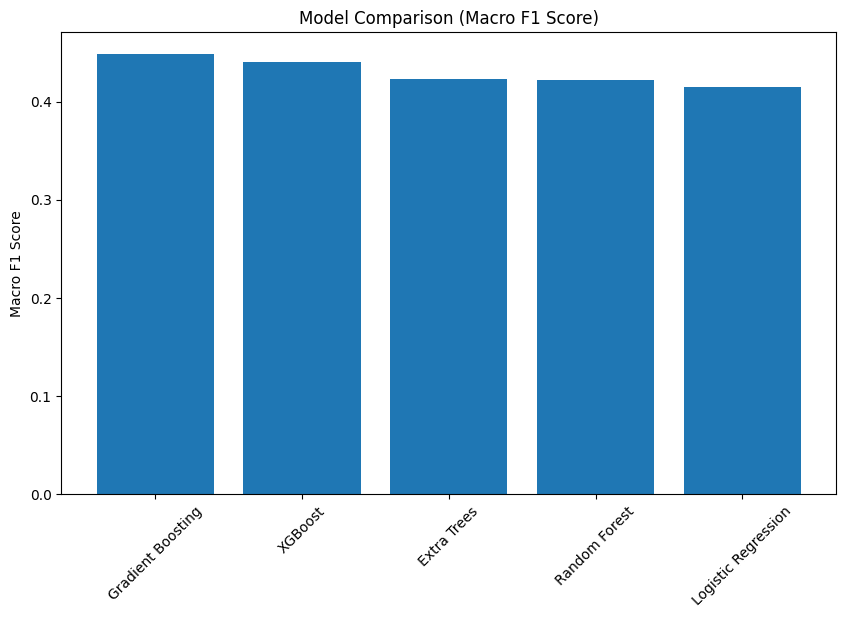

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(results_df["Model"], results_df["F1"])

plt.xticks(rotation=45)
plt.title("Model Comparison (Macro F1 Score)")
plt.ylabel("Macro F1 Score")
plt.show()


In [27]:

item_agg = order_items.groupby("order_id").agg(
    total_items=("order_item_id", "count"),
    total_price=("price", "sum"),
    total_freight=("freight_value", "sum")
).reset_index()

df = df.merge(item_agg, on="order_id", how="left")

print("Order item features added.")


Order item features added.


In [28]:
payment_agg = payments.groupby("order_id").agg(
    payment_installments=("payment_installments", "max"),
    payment_value=("payment_value", "sum")
).reset_index()

df = df.merge(payment_agg, on="order_id", how="left")

print("Payment features added.")


Payment features added.


In [29]:
review_agg = reviews.groupby("order_id").agg(
    review_score=("review_score", "mean")
).reset_index()

df = df.merge(review_agg, on="order_id", how="left")

print("Review features added.")


Review features added.


In [30]:
seller_agg = order_items.groupby("seller_id").agg(
    seller_total_orders=("order_id", "count")
).reset_index()


seller_per_order = order_items.groupby("order_id").agg(
    num_sellers=("seller_id", "nunique")
).reset_index()

df = df.merge(seller_per_order, on="order_id", how="left")

print("Correct seller features added.")

print("Final dataset shape:", df.shape)



Correct seller features added.
Final dataset shape: (96470, 37)


In [31]:
print("Final dataset shape:", df.shape)
df.head()


Final dataset shape: (96470, 37)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,num_items,total_payment,payment_installments_x,total_items,total_price,total_freight,payment_installments_y,payment_value_y,review_score_y,num_sellers_y
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,1,38.71,1.0,1,29.99,8.72,1.0,38.71,4.0,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,1,141.46,1.0,1,118.70,22.76,1.0,141.46,4.0,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1,179.12,3.0,1,159.90,19.22,3.0,179.12,5.0,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,1,72.20,1.0,1,45.00,27.20,1.0,72.20,5.0,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,1,28.62,1.0,1,19.90,8.72,1.0,28.62,5.0,1


In [32]:
from sklearn.model_selection import cross_val_score

print("Cross Validation (5-fold) — Macro F1")

for name, model in models.items():

    if name == "Logistic Regression":
        scores = cross_val_score(model, X, y, cv=5, scoring="f1_macro")
    else:
        scores = cross_val_score(model, X, y, cv=5, scoring="f1_macro")

    print(f"{name}:")
    print("Mean F1:", round(scores.mean(), 4))
    print("Std Dev :", round(scores.std(), 4))
    print("-" * 40)


Cross Validation (5-fold) — Macro F1
Logistic Regression:
Mean F1: 0.4113
Std Dev : 0.009
----------------------------------------
Random Forest:
Mean F1: 0.4212
Std Dev : 0.0061
----------------------------------------
Gradient Boosting:
Mean F1: 0.4453
Std Dev : 0.0048
----------------------------------------
Extra Trees:
Mean F1: 0.427
Std Dev : 0.0103
----------------------------------------
XGBoost:
Mean F1: 0.4432
Std Dev : 0.0045
----------------------------------------


In [33]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:", y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:", y_train_sm.value_counts())

Before SMOTE: delivery_risk
0    71330
2     3963
1     1883
Name: count, dtype: int64

After SMOTE: delivery_risk
0    71330
2    71330
1    71330
Name: count, dtype: int64


In [34]:
from xgboost import XGBClassifier

best_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    learning_rate=0.03,
    max_depth=7,
    n_estimators=800,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    min_child_weight=3,
    scale_pos_weight=8,   # Increase for minority sensitivity
    random_state=42
)
best_model.fit(X_train_sm, y_train_sm)




print("Final tuned XGBoost trained successfully.")



Final tuned XGBoost trained successfully.


Generating SHAP explanations...


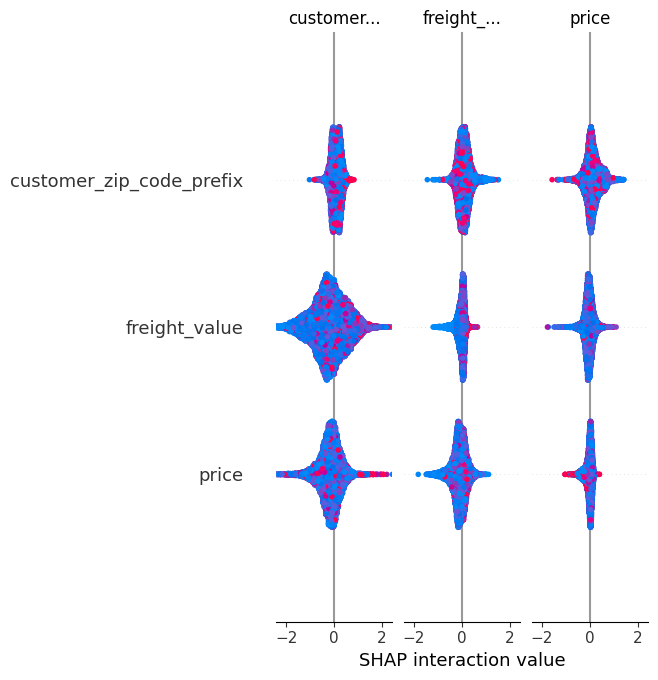

In [35]:
import shap

print("Generating SHAP explanations...")

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


In [36]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = best_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Confusion Matrix:
[[17280    24   529]
 [  414     1    56]
 [  535     0   455]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     17833
           1       0.04      0.00      0.00       471
           2       0.44      0.46      0.45       990

    accuracy                           0.92     19294
   macro avg       0.48      0.48      0.47     19294
weighted avg       0.90      0.92      0.91     19294



In [37]:
!pip install imbalanced-learn


In [38]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Macro ROC AUC
y_test_bin = label_binarize(y_test, classes=[0,1,2])
roc_macro = roc_auc_score(y_test_bin, y_proba, average="macro", multi_class="ovr")

print("\nMacro ROC-AUC:", round(roc_macro, 4))


Confusion Matrix:
[[17280    24   529]
 [  414     1    56]
 [  535     0   455]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     17833
           1       0.04      0.00      0.00       471
           2       0.44      0.46      0.45       990

    accuracy                           0.92     19294
   macro avg       0.48      0.48      0.47     19294
weighted avg       0.90      0.92      0.91     19294


Macro ROC-AUC: 0.7456


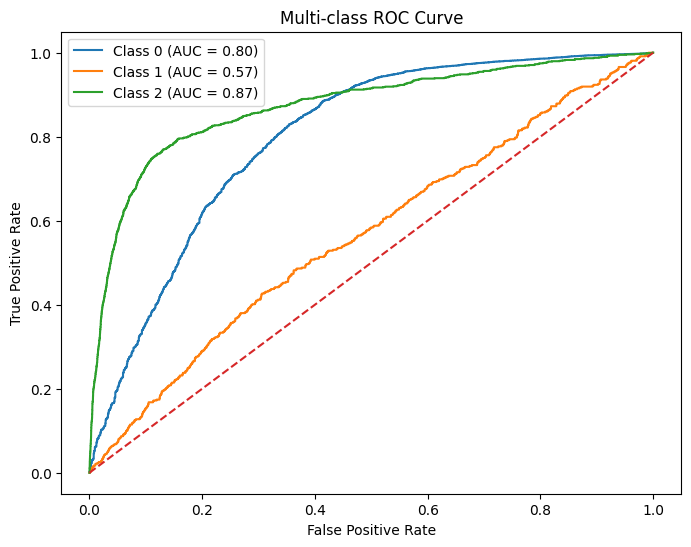

In [39]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

y_test_bin = label_binarize(y_test, classes=[0,1,2])

plt.figure(figsize=(8,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve")
plt.legend()
plt.show()


In [40]:
import joblib

joblib.dump(best_model, "delivery_risk_model.pkl")

print("Model saved successfully.")


Model saved successfully.


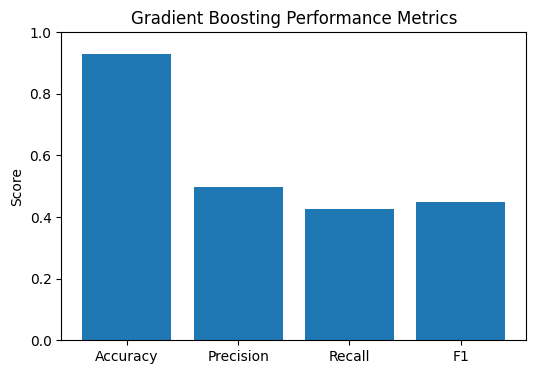

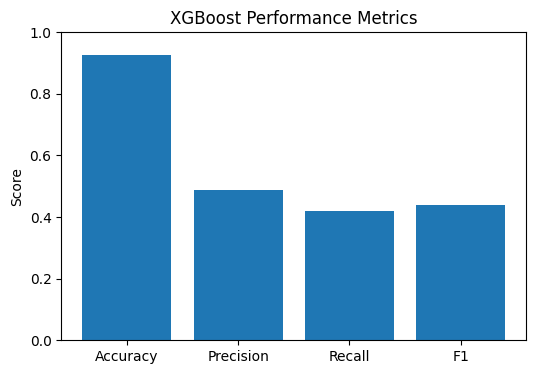

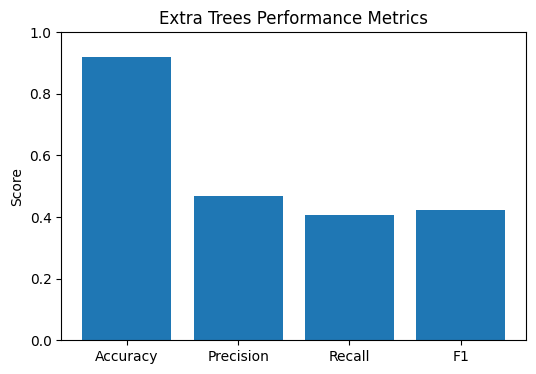

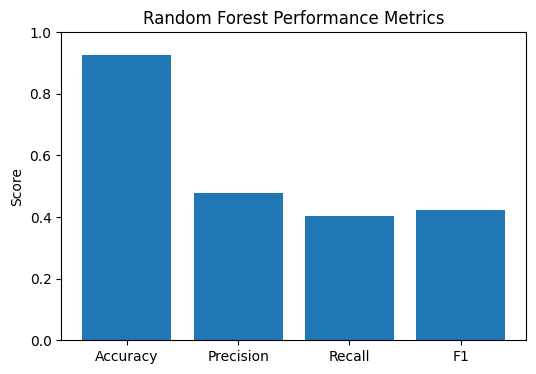

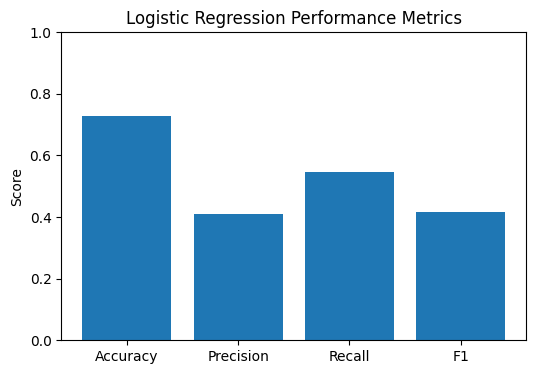

In [41]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1"]

for model_name in results_df["Model"]:
    model_data = results_df[results_df["Model"] == model_name]

    plt.figure(figsize=(6,4))
    plt.bar(metrics, model_data[metrics].values[0])
    plt.title(f"{model_name} Performance Metrics")
    plt.ylim(0,1)
    plt.ylabel("Score")
    plt.show()


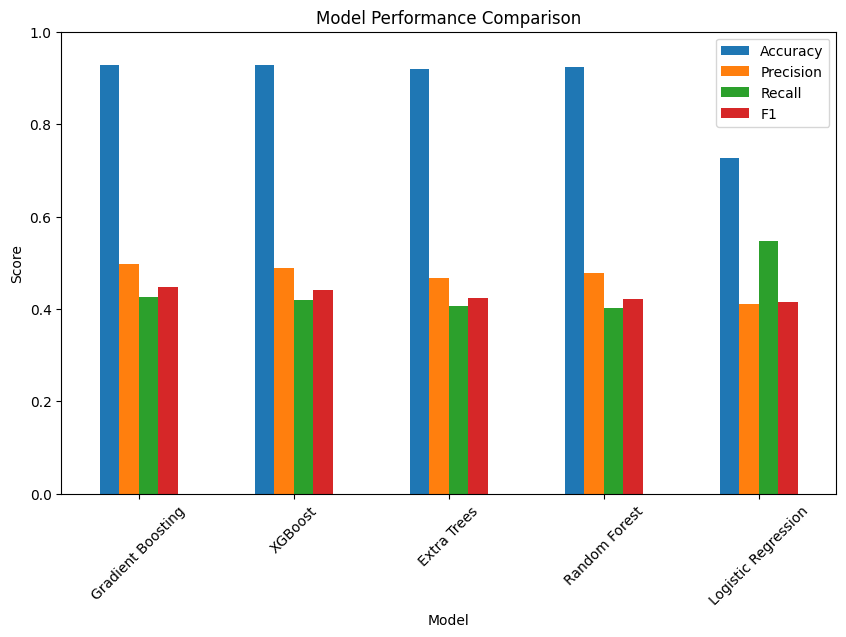

In [42]:
results_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylim(0,1)
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()


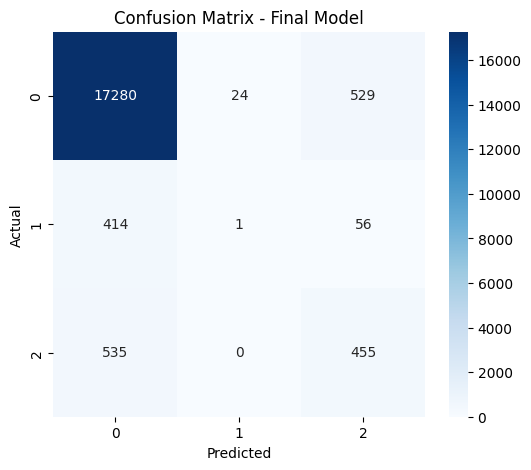

In [43]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Final Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


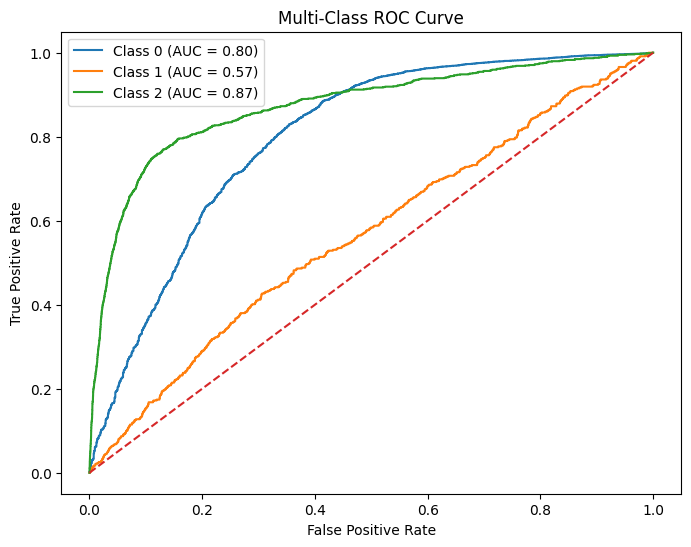

In [44]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_proba = best_model.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')
plt.title("Multi-Class ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


<Figure size 800x600 with 0 Axes>

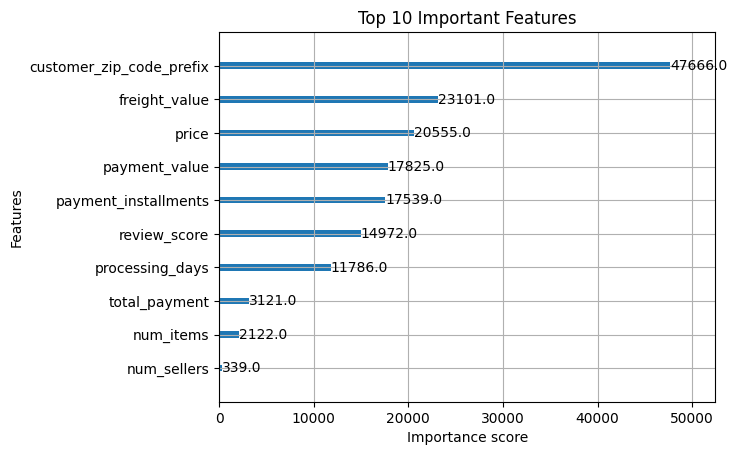

In [45]:
import xgboost as xgb

plt.figure(figsize=(8,6))
xgb.plot_importance(best_model, max_num_features=10)
plt.title("Top 10 Important Features")
plt.show()


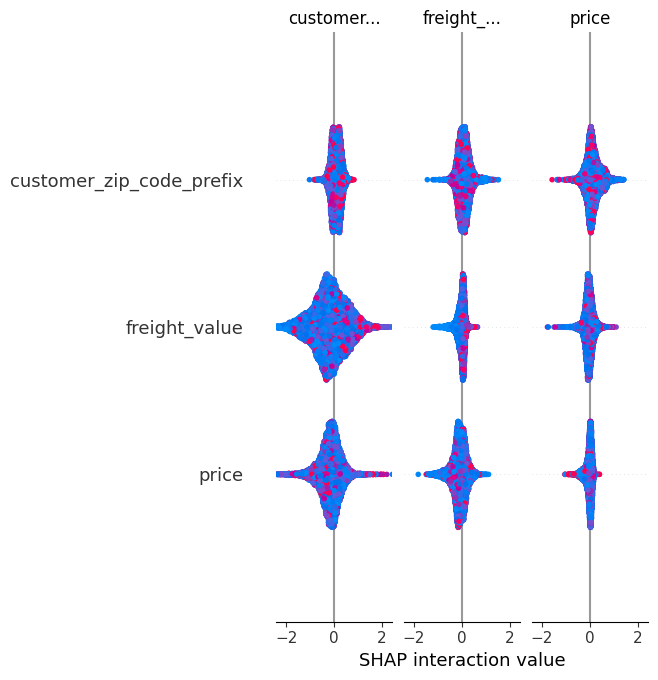

In [46]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


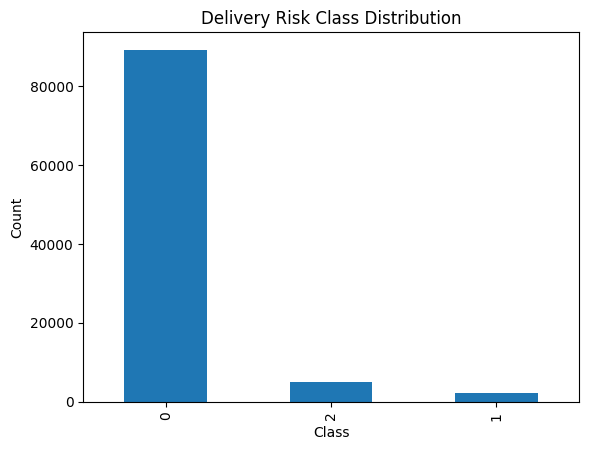

In [47]:
y.value_counts().plot(kind="bar")
plt.title("Delivery Risk Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


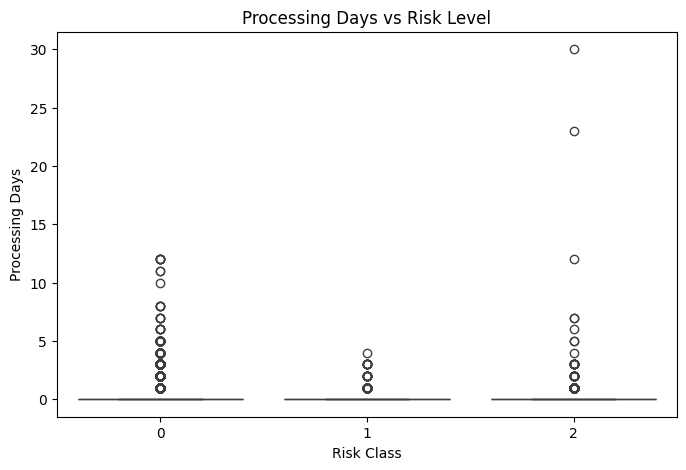

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=y_test, y=X_test["processing_days"])
plt.title("Processing Days vs Risk Level")
plt.xlabel("Risk Class")
plt.ylabel("Processing Days")
plt.show()

